# Máquinas Térmicas - Lección 8b (Bonus)
## Cinética de Combustión de Biomasa: raquis (EFB) y fibra (PMF) de palma de aceite

**Autor:** Camilo Bayona
**Fecha:** 12/08/2025

### Objetivos de aprendizaje
1. Convertir un **análisis último** real de biomasa en fórmula molecular, requerimiento de aire y concentraciones iniciales de un modelo cinético.
2. Formular y resolver el sistema completo de **EDOs acopladas** (hasta 15 especies) del artículo, leyendo críticamente sus supuestos de modelación.
3. **Calibrar** las constantes cinéticas contra un objetivo termodinámico ($LHV \times m$) y analizar perfiles de especies, energía, potencia y efecto del AFR.
4. Cuantificar el efecto de la **humedad** sobre la energía útil de cada biomasa.

In [1]:
# Instalación solo en Google Colab; en el entorno local del curso es un no-op
import sys
if "google.colab" in sys.modules:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "matplotlib", "ipywidgets", "numpy", "scipy"], check=True)

In [2]:
# === Setup =================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import brentq
from ipywidgets import interact, FloatSlider, FloatLogSlider, Dropdown
from IPython.display import display

# Paleta de especies (coherente con las Lecciones 7 y 8); menores: elemento sólido y su óxido comparten tono
COL = {"C": "#3a3a38", "H": "#2a78d6", "O2": "#e34948", "CO2": "#eda100", "H2O": "#1baf7a",
       "N2": "#8a8a86", "S": "#008300", "N": "#4a3aa7", "K": "#e87ba4", "P": "#eb6834",
       "Na": "#8a8a86", "tinta": "#3a3a38"}

# Entalpías de formación de los productos [kJ/mol] (tabla del artículo; elementos = 0)
HF = {"CO2": -393.5, "H2O": -241.82, "SO2": -296.83, "NOx": 33.2,
      "K2O": -363.2, "P2O5": -1340.0, "Na2O": -414.0}

# Masas atómicas [g/mol]
MW = {"C": 12.011, "H": 1.008, "O": 15.999, "N": 14.007, "S": 32.06,
      "K": 39.098, "P": 30.974, "Na": 22.99}

M_BASE = 8.33      # kg de biomasa seca (alimentación de 30 t/h en base por segundo, como el artículo)
V_CAM  = 360.0     # m³ — volumen de la cámara de combustión del artículo
T_SIM  = 3000.0    # ms — ventana de simulación del artículo
print("Setup OK")

Setup OK


## 1. Del análisis último al modelo

El punto de partida es el **análisis último** (Lección 7, §7): la composición elemental en base seca de cada biomasa.

**Fibra de palma (PMF)** — Idris et al. (2012): C 51.52 %, H 5.45 %, O 40.91 %, N 1.89 %, S 0.23 %.

**Raquis (EFB)** — promedio de **7 estudios** (incluido el del grupo del curso, Bayona-Roa et al.), más los inorgánicos K, P y Na reportados por García-Núñez et al., que en el raquis son relevantes porque sus sales (K, Cl) **corroen las calderas** — la razón industrial de estudiar este residuo.

De la composición salen las tres piezas del modelo, con las fórmulas de la Lección 7:

$$n_i = \frac{m\, w_i}{MW_i}, \qquad C_{i,0} = \frac{n_i}{V_{cámara}}, \qquad
m_{O_2} = \left(2.664\,w_C + 7.937\,w_H + 0.998\,w_S\right) m$$

> **Nota metodológica (lectura crítica).** El artículo calcula el aire como $m_{aire} = m_{O_2}/0.21$ — usa la fracción *volumétrica* del O$_2$ como si fuera másica y **no acredita el oxígeno propio del combustible** (41 % de la masa del raquis). Con la convención de la Lección 7 (23.2 % másico y crédito del O del combustible) los AFR estequiométricos serían ≈ 5.4 (EFB) y 6.0 (PMF) en lugar de **7.94** y **8.63** kg aire/kg. Reproducimos aquí la convención del artículo para poder comparar con sus resultados — leer un paper también es identificar sus convenciones.

EFB: fórmula (S=1): C496 H834 O350 N6 S1 | AFR_esteq (convención artículo) = 7.92 kg aire/kg
PMF: fórmula (S=1): C598 H754 O356 N19 S1 | AFR_esteq (convención artículo) = 8.61 kg aire/kg
   (el artículo reporta C488 H821 O344 N6 S para EFB — la diferencia es el redondeo del promedio)


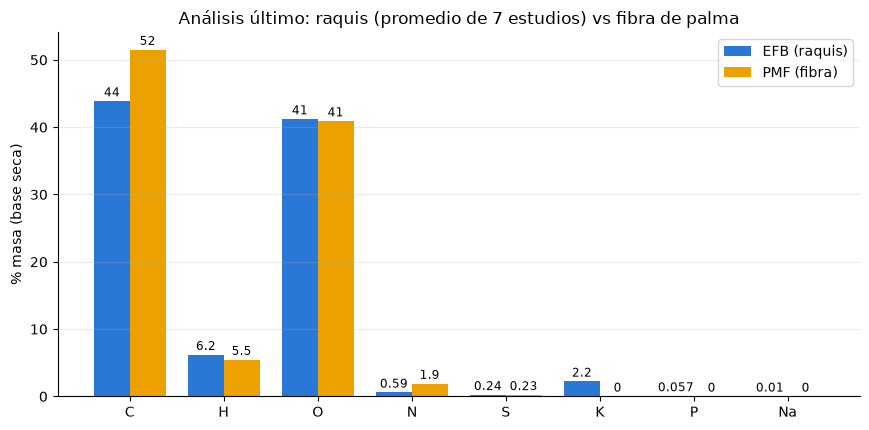

In [3]:
# Composición elemental [% masa, base seca] y datos experimentales del artículo
COMPOSICION_EFB_ESTUDIOS = {   # 7 autores; None = no reportado
    "Olisa & Kotingo 2014":  {"C": 43.8,  "H": 6.2,  "O": 42.65, "N": 0.44, "S": 0.09},
    "García-Núñez 2006":     {"C": 40.88, "H": None, "O": None,  "N": 0.87, "S": 0.09,
                              "K": 2.23,  "P": 0.057, "Na": 0.01},
    "Ninduangdee 2015":      {"C": 48.2,  "H": 6.49, "O": 31.74, "N": 0.47, "S": 0.10},
    "Madhiyanon 2012":       {"C": 40.7,  "H": 5.4,  "O": 47.0,  "N": 0.3,  "S": 1.1},
    "Ramírez 2011":          {"C": 42.8,  "H": 6.4,  "O": 35.8,  "N": 0.8,  "S": 0.1},
    "Kaniapan 2021":         {"C": 42.8,  "H": 6.2,  "O": 50.44, "N": 0.47, "S": 0.09},
    "Bayona-Roa (curso)":    {"C": 48.03, "H": 6.47, "O": 39.65, "N": 0.77, "S": 0.084},
}
def promedio(el):
    vals = [d.get(el) for d in COMPOSICION_EFB_ESTUDIOS.values() if d.get(el) is not None]
    return sum(vals) / len(vals)

W = {  # fracciones másicas [%] en base seca
    "EFB": {el: promedio(el) for el in ["C", "H", "O", "N", "S", "K", "P", "Na"]},
    "PMF": {"C": 51.52, "H": 5.45, "O": 40.91, "N": 1.89, "S": 0.23, "K": 0, "P": 0, "Na": 0},
}
LHV = {"EFB": 17.66, "PMF": 19.0}          # MJ/kg (promedios de literatura usados en el artículo)
HUMEDAD = {"EFB": 48.49, "PMF": 7.8}       # % humedad inherente reportada

def moles_y_afr(fuel, m_kg=M_BASE):
    w = {el: v/100 for el, v in W[fuel].items()}
    n = {el: m_kg*1000*w[el]/MW[el] for el in w}                 # moles de cada elemento
    m_O2 = (2.664*w["C"] + 7.937*w["H"] + 0.998*w["S"]) * m_kg   # kg O2 (convención del artículo)
    AFR = m_O2 / 0.21 / m_kg                                     # kg aire/kg comb. (convención del artículo)
    return n, m_O2, AFR

for fuel in ["EFB", "PMF"]:
    n, m_O2, AFR = moles_y_afr(fuel)
    formula = " ".join(f"{el}{n[el]/n['S']:.0f}" for el in ["C", "H", "O", "N", "S"])
    print(f"{fuel}: fórmula (S=1): {formula} | AFR_esteq (convención artículo) = {AFR:.2f} kg aire/kg")
print("   (el artículo reporta C488 H821 O344 N6 S para EFB — la diferencia es el redondeo del promedio)")

# composición comparada — gráfico generado por código
fig, ax = plt.subplots(figsize=(8.8, 4.4))
elems = ["C", "H", "O", "N", "S", "K", "P", "Na"]
xx = np.arange(len(elems)); ancho = 0.38
ax.bar(xx - ancho/2, [W["EFB"][e] for e in elems], ancho, label="EFB (raquis)", color="#2a78d6")
ax.bar(xx + ancho/2, [W["PMF"][e] for e in elems], ancho, label="PMF (fibra)", color="#eda100")
for i, e in enumerate(elems):
    ax.text(i - ancho/2, W["EFB"][e] + 0.7, f"{W['EFB'][e]:.2g}", ha="center", fontsize=8.5)
    ax.text(i + ancho/2, W["PMF"][e] + 0.7, f"{W['PMF'][e]:.2g}", ha="center", fontsize=8.5)
ax.set_xticks(xx, elems); ax.set_ylabel("% masa (base seca)")
ax.set_title("Análisis último: raquis (promedio de 7 estudios) vs fibra de palma")
ax.legend(); ax.grid(axis="y", alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 2. El sistema de EDOs acopladas

El artículo modela la biomasa como **elementos que compiten por el O$_2$** — la generalización directa del anticipo de la Lección 8. Rastreamos 12 especies para PMF y 15 para EFB. Cada reacción usa el término bilineal normalizado del artículo, $r_i = k_i X_i X_{O_2}/N$, y nosotros cerramos la estequiometría con los coeficientes correctos (Lección 8, §3 — el artículo publica ecuaciones tipo "SIR literal" que no conservan átomos; aquí las corregimos manteniendo su jerarquía de constantes):

$$\begin{aligned}
C + O_2 &\rightarrow CO_2, & r_C &= k_C X_C X_{O_2}/N\\
4H + O_2 &\rightarrow 2H_2O, & r_H &= k_H X_H X_{O_2}/N\\
S + O_2 &\rightarrow SO_2, & r_S &= k_S X_S X_{O_2}/N\\
N + O_2 &\rightarrow NO_2\ (NO_x), & r_N &= k_N X_N X_{O_2}/N\\
4K + O_2 &\rightarrow 2K_2O, & r_K &= k_K X_K/N \quad (\text{1er orden, como el artículo})\\
4P + 5O_2 &\rightarrow 2P_2O_5, & r_P &= k_P X_P/N\\
4Na + O_2 &\rightarrow 2Na_2O, & r_{Na} &= k_{Na} X_{Na}/N
\end{aligned}$$

**Supuestos heredados del artículo (léelos críticamente):**
1. **$k$ constantes** (sin Arrhenius): el rango de temperatura del hogar es estrecho y las constantes están *calibradas*, no medidas — ganancia en estabilidad numérica, pérdida de la dinámica de ignición (Lección 8, §7).
2. Los **inorgánicos** (K, P, Na) oxidan con cinética de **primer orden** (sin encuentro con O$_2$ en el término): son sales en la ceniza, no gas premezclado.
3. Combustión **homogénea 0D** de un sólido (como en la Lección 8, §4) y **base seca** (la humedad se descuenta después, §5).
4. El N$_2$ del aire es inerte; el N del combustible sí oxida a NO$_x$ (endotérmico: $\Delta H^\circ_f = +33.2$ kJ/mol).

La **energía** sale de las entalpías de formación (Lección 7): $E(t) = \sum_{prod} n_j(t)\,|\Delta H^\circ_{f,j}|$ con el signo de cada producto, y la **potencia** es su derivada.

In [4]:
# Modelo cinético: especies, EDOs y energía
ESPECIES = ["C", "H", "S", "N", "K", "P", "Na", "O2", "N2",
            "CO2", "H2O", "SO2", "NOx", "K2O", "P2O5", "Na2O"]
K_BASE = {  # jerarquía de constantes del artículo [tabla]: EFB y PMF
    "EFB": {"C": 1.07e-7, "H": 6.42e-7, "N": 1.71e-7, "S": 2.14e-7,
            "K": 2.14e-7, "P": 1.71e-7, "Na": 1.71e-7},
    "PMF": {"C": 1.07e-5, "H": 6.42e-7, "N": 1.71e-7, "S": 2.14e-7,
            "K": 0.0, "P": 0.0, "Na": 0.0},
}

def estado_inicial(fuel, factor_aire=1.0, m_kg=M_BASE):
    n, m_O2, AFR = moles_y_afr(fuel, m_kg)
    X0 = {sp: 0.0 for sp in ESPECIES}
    for el in ["C", "H", "S", "N", "K", "P", "Na"]:
        X0[el] = n.get(el, 0.0) / V_CAM                          # mol/m³
    n_O2 = factor_aire * m_O2 * 1000 / (2 * MW["O"])
    X0["O2"] = n_O2 / V_CAM
    X0["N2"] = 3.76 * n_O2 / V_CAM
    return X0

def deriv(y, t, k):
    X = dict(zip(ESPECIES, y))
    N = max(sum(y), 1e-12)
    O2 = max(X["O2"], 0.0)
    rC = k["C"] * X["C"] * O2 / N
    rH = k["H"] * X["H"] * O2 / N
    rS = k["S"] * X["S"] * O2 / N
    rN = k["N"] * X["N"] * O2 / N
    rK = k["K"] * X["K"] / N
    rP = k["P"] * X["P"] / N
    rNa = k["Na"] * X["Na"] / N
    d = {sp: 0.0 for sp in ESPECIES}
    d["C"], d["CO2"] = -rC, rC
    d["H"], d["H2O"] = -rH, rH / 2
    d["S"], d["SO2"] = -rS, rS
    d["N"], d["NOx"] = -rN, rN
    d["K"], d["K2O"] = -rK, rK / 2
    d["P"], d["P2O5"] = -rP, rP / 2
    d["Na"], d["Na2O"] = -rNa, rNa / 2
    d["O2"] = -(rC + rH/4 + rS + rN + rK/4 + rP*5/4 + rNa/4)
    return [d[sp] for sp in ESPECIES]

def simular(fuel, mult=1.0, factor_aire=1.0, m_kg=M_BASE, t_ms=T_SIM, npts=1200):
    k = {el: v * mult for el, v in K_BASE[fuel].items()}
    X0 = estado_inicial(fuel, factor_aire, m_kg)
    t = np.linspace(0.0, t_ms / 1000.0, npts)                    # [s]
    sol = odeint(deriv, [X0[sp] for sp in ESPECIES], t, args=(k,),
                 rtol=1e-8, atol=1e-12)
    Xs = dict(zip(ESPECIES, sol.T))
    # energía liberada acumulada [MJ] = Σ productos formados (moles) × (−ΔHf)
    E = sum(Xs[p] * V_CAM * (-HF[p]) for p in HF) / 1000.0       # MJ
    P = np.gradient(E, t) * 1000.0                                # kW
    return t * 1000.0, Xs, E, P                                   # t en [ms]
print("Modelo listo:", len(ESPECIES), "especies")

Modelo listo: 16 especies


## 3. Calibración: la cinética al servicio de la termodinámica

Las $k_i$ del artículo no se miden: se **calibran** para que la energía liberada en la ventana de 3000 ms coincida con el objetivo termodinámico de la Lección 7,

$$E_t = LHV \times m = \begin{cases} 17.66 \times 8.33 = \mathbf{147.11\ MJ} & \text{(EFB)}\\ 19 \times 8.33 = \mathbf{158.27\ MJ} & \text{(PMF)} \end{cases}$$

preservando las **proporciones** entre constantes (la jerarquía de reactividades). El artículo lo hace iterando a mano; nosotros automatizamos esa iteración con un buscador de raíces sobre un multiplicador global $\mu$: se busca $\mu$ tal que $E_{sim}(3000\ \text{ms}; \mu \cdot k_i) = E_t$ — exactamente el procedimiento descrito en su sección de solución numérica, pero reproducible con una línea de `scipy`.

In [5]:
# Calibración automática del multiplicador global μ (bisección sobre log10 μ)
OBJETIVO = {f: LHV[f] * M_BASE for f in ["EFB", "PMF"]}   # 147.11 y 158.27 MJ

MULT = {}
for fuel in ["EFB", "PMF"]:
    f_err = lambda log_mu: simular(fuel, 10.0**log_mu, npts=400)[2][-1] - OBJETIVO[fuel]
    MULT[fuel] = 10.0 ** brentq(f_err, 0.0, 12.0, xtol=1e-4)
    E_fin = simular(fuel, MULT[fuel], npts=400)[2][-1]
    print(f"{fuel}: μ = {MULT[fuel]:.3e} → E(3000 ms) = {E_fin:.2f} MJ (objetivo {OBJETIVO[fuel]:.2f} MJ)")
    print("      k calibradas [1/s]: " + ", ".join(
        f"k_{el}={v*MULT[fuel]:.2e}" for el, v in K_BASE[fuel].items() if v > 0))

EFB: μ = 5.684e+07 → E(3000 ms) = 147.11 MJ (objetivo 147.11 MJ)
      k calibradas [1/s]: k_C=6.08e+00, k_H=3.65e+01, k_N=9.72e+00, k_S=1.22e+01, k_K=1.22e+01, k_P=9.72e+00, k_Na=9.72e+00
PMF: μ = 4.775e+06 → E(3000 ms) = 158.27 MJ (objetivo 158.27 MJ)
      k calibradas [1/s]: k_C=5.11e+01, k_H=3.07e+00, k_N=8.16e-01, k_S=1.02e+00


## 4. Perfiles de especies, energía y potencia

Con el modelo calibrado exploramos la combustión de cada biomasa. Compara con las figuras del artículo: la fibra libera ~80 % de su energía en los primeros 1000 ms y el raquis es más lento; los inorgánicos del raquis (K, P, Na) casi no aportan energía pero **sí aparecen en los productos** — son las sales corrosivas de la ceniza.

In [ ]:
# WIDGET A — perfiles de especies, energía y potencia del modelo calibrado
def perfiles(fuel="PMF", mult_rel=1.0, factor_aire=1.0):
    mult = MULT[fuel] * mult_rel
    t, Xs, E, P = simular(fuel, mult, factor_aire)
    fig, axs = plt.subplots(4, 1, figsize=(9, 11.5), sharex=True,
                            gridspec_kw={"height_ratios": [2, 1.3, 1.1, 1.1]})
    ax = axs[0]   # especies mayores
    for sp, c, ls in [("C", COL["C"], "-"), ("H", COL["H"], "-"), ("O2", COL["O2"], "-"),
                      ("CO2", COL["CO2"], "-"), ("H2O", COL["H2O"], "-"), ("N2", COL["N2"], ":")]:
        ax.plot(t, Xs[sp], color=c, ls=ls, lw=2.2, label=sp)
    ax.set_ylabel("concentración [mol/m³]")
    ax.set_title(f"{fuel} — especies mayores (μ×{mult_rel:g}, aire×{factor_aire:g})")
    ax.legend(ncol=3); ax.grid(alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
    ax = axs[1]   # especies menores: elemento sólido (línea llena) y su óxido (discontinua)
    menores = [("S", "SO2", COL["S"]), ("N", "NOx", COL["N"]),
               ("K", "K2O", COL["K"]), ("P", "P2O5", COL["P"])]
    for el, ox, c in menores:
        if Xs[el][0] > 0:
            ax.plot(t, Xs[el], color=c, lw=2.0, label=el)
            ax.plot(t, Xs[ox], color=c, lw=2.0, ls="--", label=ox)
    ax.set_ylabel("concentración [mol/m³]")
    ax.set_title("especies menores (elemento —, óxido - -)", fontsize=10)
    ax.legend(ncol=4, fontsize=9); ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
    ax = axs[2]   # energía acumulada
    ax.plot(t, E, color=COL["tinta"], lw=2.4)
    i80 = min(int(np.searchsorted(E, 0.8 * E[-1])), len(t) - 1)
    ax.axvline(t[i80], color=COL["tinta"], ls=":", lw=1)
    ax.annotate(f"80 % de la energía en {t[i80]:.0f} ms",
                xy=(t[i80], 0.8*E[-1]), xytext=(t[-1]*0.45, E[-1]*0.3),
                fontsize=10, color=COL["tinta"],
                arrowprops=dict(arrowstyle="->", color=COL["tinta"], lw=1))
    ax.set_ylabel("E [MJ]")
    ax.set_title(f"E(3000 ms) = {E[-1]:.1f} MJ | objetivo LHV·m = {OBJETIVO[fuel]:.2f} MJ", fontsize=10)
    ax.grid(alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
    ax = axs[3]   # potencia
    ax.plot(t, P, color="#eb6834", lw=2.2)
    ax.fill_between(t, P, color="#eb6834", alpha=0.15)
    ax.set_xlabel("tiempo [ms]"); ax.set_ylabel("potencia [kW]")
    ax.set_title(f"pico de potencia {P.max():,.0f} kW en {t[np.argmax(P)]:.0f} ms", fontsize=10)
    ax.grid(alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(perfiles,
         fuel=Dropdown(options=["PMF", "EFB"], description="biomasa"),
         mult_rel=FloatLogSlider(1.0, base=10, min=-1.5, max=1.5, step=0.1,
                                 description="μ relativo"),
         factor_aire=FloatSlider(1.0, min=0.4, max=2.5, step=0.05, description="aire × esteq"));

interactive(children=(Dropdown(description='biomasa', options=('PMF', 'EFB'), value='PMF'), FloatLogSlider(val…

## 5. Efecto del AFR sobre el calor liberado

El artículo barre el AFR y encuentra que el **raquis alcanza su máximo de calor con menos aire que la fibra** (picos en 7.94 vs 8.63 kg aire/kg — las composiciones mandan), y que con defecto de aire el EFB conserva una fracción mayor de su energía: ventaja en hogares con tiro limitado. Reproducimos el barrido: calor liberado en la ventana de simulación **por kg de mezcla** (combustible + aire), como en la Lección 7 §4.4 pero ahora con la cinética en el tiempo.

**Punto de discusión:** el artículo evalúa combustión *completa* y por eso su pico cae exactamente en el AFR estequiométrico; en nuestro modelo calibrado el pico aparece **por debajo** del estequiométrico porque la ventana de 3000 ms es finita — con más aire la mezcla pesa más, pero la energía adicional ya no alcanza a liberarse dentro de la ventana. Alarga la ventana con el slider y observa cómo el pico migra hacia las líneas punteadas (el estequiométrico). En ambos casos se preserva el hallazgo central: **el EFB rinde mejor con menos aire que el PMF**.

In [7]:
# WIDGET B — barrido de AFR: calor liberado por kg de mezcla (ventana de t_vent ms)
def barrido_afr(t_vent=3000.0):
    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    resumen = []
    for fuel, c in [("EFB", "#2a78d6"), ("PMF", "#eda100")]:
        _, m_O2, AFR_st = moles_y_afr(fuel)
        factores = np.linspace(0.3, 3.0, 22)
        AFRs = factores * AFR_st
        q = []
        for fa in factores:
            E = simular(fuel, MULT[fuel], fa, t_ms=t_vent, npts=300)[2][-1]
            q.append(E * 1000.0 / (M_BASE * (1.0 + fa * AFR_st)))   # kJ por kg de mezcla
        q = np.array(q)
        ax.plot(AFRs, q, color=c, lw=2.4, label=fuel)
        i_max = int(np.argmax(q))
        ax.plot(AFRs[i_max], q[i_max], "o", ms=9, color=c, mec="white", mew=1.5)
        ax.axvline(AFR_st, color=c, lw=1.0, ls=":", alpha=0.8)
        resumen.append(f"{fuel}: pico en AFR ≈ {AFRs[i_max]:.1f} (esteq. {AFR_st:.2f})")
    ax.set_xlabel("AFR [kg aire/kg combustible]")
    ax.set_ylabel(f"calor liberado en {t_vent:.0f} ms [kJ/kg de mezcla]")
    ax.set_title(" | ".join(resumen) + "\n(punteadas: AFR estequiométrico de cada biomasa)")
    ax.legend(title="biomasa"); ax.grid(alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(barrido_afr,
         t_vent=FloatSlider(3000, min=500, max=3000, step=250, description="ventana [ms]"));

interactive(children=(FloatSlider(value=3000.0, description='ventana [ms]', max=3000.0, min=500.0, step=250.0)…

## 6. Efecto de la humedad: la energía útil

Todo lo anterior es **base seca** — el supuesto explícito del artículo. Pero el raquis sale del proceso de extracción con **48.5 % de humedad** y la fibra con **7.8 %**. Evaporar esa agua cuesta energía que la caldera ya no recibe:

$$E_{útil} = LHV \cdot m_{seco} \;-\; m_{agua}\left[c_{p,w}(100-25) + h_{fg}\right], \qquad h_{fg} = 2257\ \text{kJ/kg}$$

El artículo estima esta penalización en ≈ 1.9 % para la fibra y ≈ 15 % para el raquis: la ventaja de LHV de la fibra **se amplifica** si no hay secado previo — y de ahí la recomendación de ingeniería: **secar el raquis antes de quemarlo**.

In [8]:
# WIDGET C — energía útil vs humedad (por 8.33 kg de biomasa seca + su agua)
def energia_util(w_pct, fuel):
    m_seco = M_BASE
    m_agua = m_seco * w_pct / (100.0 - w_pct)          # humedad en base húmeda
    Q_evap = m_agua * (4.18 * 75 + 2257.0) / 1000.0    # MJ (calentar 25→100 °C + evaporar)
    return OBJETIVO[fuel] - Q_evap, Q_evap

def humedad(w_EFB=48.49, w_PMF=7.8):
    ws = np.linspace(0, 60, 200)
    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    for fuel, c, w_act in [("EFB", "#2a78d6", w_EFB), ("PMF", "#eda100", w_PMF)]:
        Es = np.array([energia_util(w, fuel)[0] for w in ws])
        ax.plot(ws, Es, color=c, lw=2.4, label=fuel)
        E_act, Q_ev = energia_util(w_act, fuel)
        ax.plot(w_act, E_act, "o", ms=9, color=c, mec="white", mew=1.5)
        ax.annotate(f"{fuel} a {w_act:.1f} %:\n{E_act:.0f} MJ útiles (−{Q_ev/OBJETIVO[fuel]*100:.1f} %)",
                    xy=(w_act, E_act), xytext=(w_act + 4, E_act - 14), fontsize=10,
                    color=COL["tinta"], arrowprops=dict(arrowstyle="->", color=COL["tinta"], lw=1))
    ax.set_xlabel("humedad [% base húmeda]")
    ax.set_ylabel(f"energía útil por {M_BASE} kg secos [MJ]")
    ax.set_title("La humedad castiga más al raquis: secar antes de quemar")
    ax.legend(title="biomasa"); ax.grid(alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(humedad,
         w_EFB=FloatSlider(48.49, min=0, max=60, step=0.5, description="humedad EFB %"),
         w_PMF=FloatSlider(7.8, min=0, max=60, step=0.5, description="humedad PMF %"));

interactive(children=(FloatSlider(value=48.49, description='humedad EFB %', max=60.0, step=0.5), FloatSlider(v…

## Conclusión

Este bonus cierra el arco Lecciones 7 → 8 → 8b: un **análisis último** real (L7) alimenta un sistema de **EDOs acopladas** (L8) cuyas constantes se **calibran contra la termodinámica** ($LHV \times m$), y el modelo resultante responde preguntas de ingeniería que los balances estáticos no alcanzan: cuánta potencia entrega la caldera en el tiempo, con cuánto aire conviene operar cada biomasa y cuánto castiga la humedad. También practicamos **lectura crítica de un artículo**: identificamos sus convenciones (AFR sin crédito del O del combustible), sus supuestos ($k$ constantes, primer orden para inorgánicos) y corregimos su estequiometría no conservativa con las herramientas de la Lección 8. Ciencia de frontera hecha en el curso, convertida en herramienta de aula.

---
### Referencias
- Arias-Guerrero, D. A., Castillo-Hernández, M., Mayorga-Guzmán, J. D. & Bayona-Roa, C. A. *Computational Modeling of the Combustion Reaction Kinetics of the Oil Palm's Empty Fruit Bunch and Mesocarp Fiber* Biofuels, 17(6), 1306–1325. https://doi.org/10.1080/17597269.2025.2599597.
- Idris, S. S. et al. (2012). Combustion characteristics of Malaysian oil palm biomass. *Bioresource Technology*.
- García-Núñez, J. A. et al. (2006). Caracterización de biomasa de palma. *Revista Palmas* (Cenipalma).
- Hindmarsh, A. C. (1983). ODEPACK — el algoritmo LSODA que usa `scipy.integrate.odeint`.